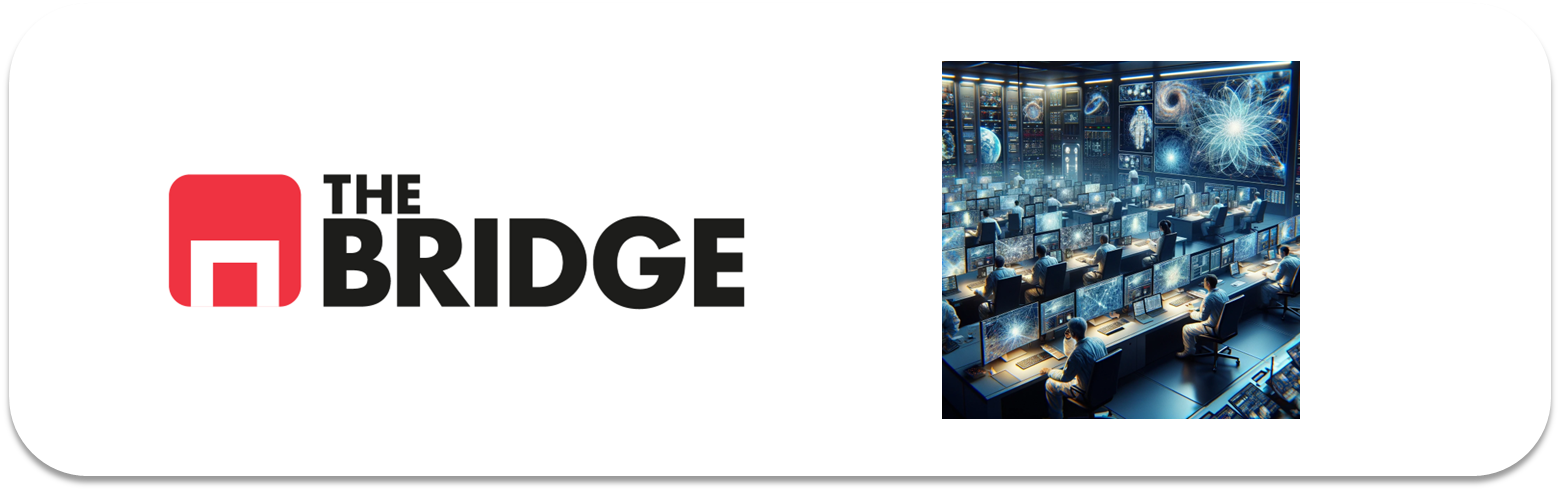

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [85]:
import os
import numpy as np
import cv2
from skimage.io import imread

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



In [1]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.gpu_device_name())

Num GPUs Available:  0



In [86]:
ROOT_PATH = "./data/"
TRAIN_PATH = ROOT_PATH + "seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/"

In [87]:
import os

print(os.listdir("./data"))

['seg_pred', 'seg_test', 'seg_train']


In [88]:
def read_data(directorio, reshape_dim=(96,96)):

    X = []
    y = []

    for folder in os.listdir(directorio):

        if os.path.isdir(os.path.join(directorio, folder)):

            for file in os.listdir(os.path.join(directorio, folder)):

                if file.endswith(".jpg"):  # SOLO imágenes

                    image = imread(os.path.join(directorio, folder, file))

                    image = cv2.resize(image, reshape_dim)

                    X.append(image)
                    y.append(folder)

    return np.array(X), np.array(y)

In [89]:
X_train, y_train = read_data(TRAIN_PATH)
X_test, y_test = read_data(TEST_PATH)

In [90]:
print(os.listdir(TRAIN_PATH))

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'seg_train', 'street']


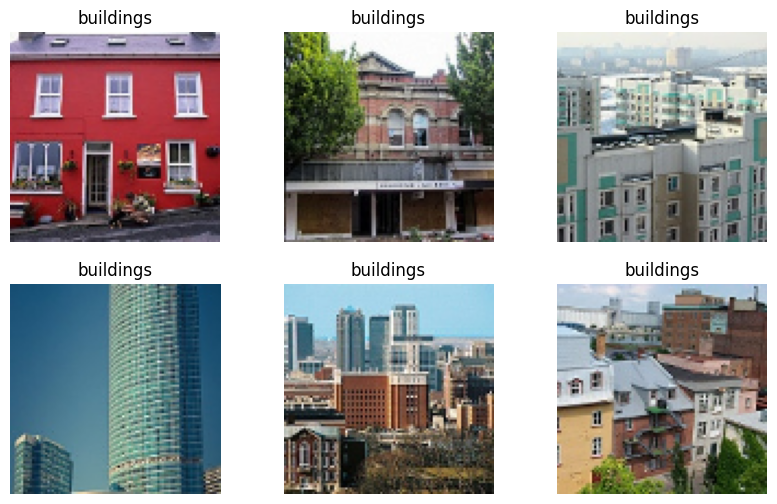

In [91]:
plt.figure(figsize=(10,6))

for i in range(6):

    plt.subplot(2,3,i+1)
    plt.imshow(X_train[i])
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

In [92]:
# ver la forma de los datos
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (14020, 96, 96, 3)
y_train: (14020,)
X_test: (3000, 96, 96, 3)
y_test: (3000,)


In [93]:
# las clases del problema
np.unique(y_train)

array(['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'],
      dtype='<U9')

In [94]:
# convertir etiquetas a numeros
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [95]:
# One hot encoding
from tensorflow.keras.utils import to_categorical

num_classes = len(np.unique(y_train))

y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

In [96]:
# Normalizar las imágenes
X_train = X_train / 255.0
X_test = X_test / 255.0


In [97]:
# comprobar rango de valores
print(X_train.min(), X_train.max())

0.0 1.0


In [98]:
# Pipeline de preparación
X_train, y_train = read_data(TRAIN_PATH)
X_test, y_test = read_data(TEST_PATH)

In [99]:
# visualización de imágenes
# comprobar forma
print(X_train.shape)
print(X_test.shape)

# convertir etiquetas
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# one hot encoding
from tensorflow.keras.utils import to_categorical
num_classes = len(np.unique(y_train))

y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

# normalizar imágenes
X_train = X_train / 255.0
X_test = X_test / 255.0

(14020, 96, 96, 3)
(3000, 96, 96, 3)


Tras cargar las imágenes del dataset se realiza una preparación de los datos para el modelo. Primero se inspecciona la forma de los arrays y las clases presentes. Posteriormente se transforman las etiquetas mediante LabelEncoder y One-Hot Encoding para adaptarlas a un problema de clasificación multiclase. Finalmente, las imágenes se normalizan dividiendo los valores de píxel entre 255 para facilitar el entrenamiento de la red neuronal.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.  

Aquí te piden elegir el modelo preentrenado sobre el que vas a hacer:  
Transfer Learning  
Fine Tuning  
La mejor opción es MobileNetV2.  
Porque:  
es más ligera  
entrena más rápido  
consume menos recursos  
suele ir muy bien si trabajas en local y no tienes un ordenador muy potente  
Además, en la propia práctica ya te lo sugieren.  


Después de elegir el modelo, lo normal es:  
Cargar el modelo  

In [2]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

In [3]:
# congelar el modelo base
base_model.trainable = False

In [4]:
# Añadir la cabeza de clasificación 
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(6, activation="softmax")
])

In [5]:
# compilar
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [6]:
# resumen 
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [105]:
# Entrenar el modelo (Transfer Learning)  
# esto entrena las capas nueva porque congelamos MobileNet
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.8807 - loss: 0.3324 - val_accuracy: 0.1384 - val_loss: 8.0281
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.9197 - loss: 0.2217 - val_accuracy: 0.1366 - val_loss: 14.2571
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 59ms/step - accuracy: 0.9312 - loss: 0.1861 - val_accuracy: 0.1355 - val_loss: 14.5502
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - accuracy: 0.9390 - loss: 0.1613 - val_accuracy: 0.1394 - val_loss: 13.6000
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.9494 - loss: 0.1436 - val_accuracy: 0.1402 - val_loss: 15.8329
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.9495 - loss: 0.1278 - val_accuracy: 0.1362 - val_loss: 17.9765
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.9607 - loss: 0.1100 - val_accuracy: 0.1398 - val_loss: 19.2019
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.9603 - loss: 0.1

In [106]:
# Evaluación en el conjunto de test
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.7547 - loss: 4.4368
Test accuracy: 0.7546666860580444


In [107]:
# Predicciones 
import numpy as np

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step


In [108]:
# Clasification Report
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.49      0.98      0.65       437
           1       0.92      1.00      0.96       474
           2       0.83      0.80      0.81       553
           3       0.77      0.89      0.83       525
           4       0.96      0.89      0.92       510
           5       0.00      0.00      0.00       501

    accuracy                           0.75      3000
   macro avg       0.66      0.76      0.70      3000
weighted avg       0.67      0.75      0.70      3000



c:\Users\diana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\diana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\diana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

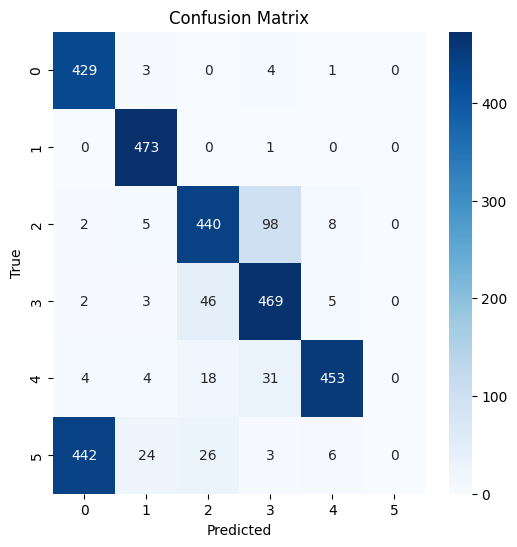

In [109]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

Paso 4 -> Hacer fine-tuning con la misma cabeza diseñada en el punto anterior  
1️⃣ descongelar parte de MobileNet
2️⃣ seguir entrenando

In [ ]:
# Descongelar el modelo base
# Recompilar y entrenar otra vez
base_model.trainable = True


# Congelar solo las primeras capas, así el modelo adapta mejor al dataser de paisajes
# No queremos modificar todo MobileNet, solo las últimas capas.
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [ ]:
# recompilar el modelo -> Cuando cambias qué capas entrenan, hay que recompilar.
# Usamos learning rate pequeño porque ya partimos de pesos buenos.  
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Ver resumen del modelo - Ahora vemos que más parámetros son entrenables.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 1,370,822 (5.23 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [114]:
# Entrenar nuevamente (FIne - Tuning) -> Aquí el modelo ajusta las últimas capas de MobileNet.
history_finetune = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 80ms/step - accuracy: 0.8139 - loss: 0.8128 - val_accuracy: 0.1270 - val_loss: 25.8944
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 28s 79ms/step - accuracy: 0.8905 - loss: 0.3565 - val_accuracy: 0.1316 - val_loss: 27.3067
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.9083 - loss: 0.2748 - val_accuracy: 0.1327 - val_loss: 28.3066
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.9215 - loss: 0.2230 - val_accuracy: 0.1345 - val_loss: 28.1353
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - accuracy: 0.9306 - loss: 0.1921 - val_accuracy: 0.1355 - val_loss: 27.7408


In [113]:
# Evaluamos otra vez en test 
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test accuracy after fine tuning:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.7547 - loss: 4.4368
Test accuracy after fine tuning: 0.7546666860580444


In [115]:
# Clasificacion report
from sklearn.metrics import classification_report
import numpy as np

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes))

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step
              precision    recall  f1-score   support

           0       0.49      0.98      0.65       437
           1       0.95      0.99      0.97       474
           2       0.81      0.83      0.82       553
           3       0.83      0.84      0.84       525
           4       0.91      0.92      0.91       510
           5       0.00      0.00      0.00       501

    accuracy                           0.76      3000
   macro avg       0.66      0.76      0.70      3000
weighted avg       0.67      0.76      0.70      3000



c:\Users\diana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\diana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\diana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [ ]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()